In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Maße in MILLIMETER
l = 1100
b = 360
t = 3.8
c = 12    #höhe in der mitte
a = c/((l/2)**2)
step = 40

# def f(x,y): # c - a * (x-l/2)²  
#     """
#     diese Funktion bestimmt die Verwerfung der gemessenen Glasplatte
#     Achtung nicht zu verwechseln mit der rechten Seite 'f', aus der Thematik der PDEs, (bei uns die Eigenlast 'q')!
#     """
#     return c - a * (x-l/2)**2 


#filename_startwerte = "3.6_messwert.xyz"
filename_startwerte = f"{t}mm_startwerte.xyz"
filename_gravitation = f"{t}mm_gravitation.xyz"

data_startwerte = np.loadtxt(filename_startwerte)
data_gravitation = np.loadtxt(filename_gravitation)

#startwerte
x_SW = data_startwerte[:,0]
y_SW = data_startwerte[:,1]
z_SW = data_startwerte[:,2]


#gravitationswerte
x_GRAV = data_gravitation[:,0]
y_GRAV = data_gravitation[:,1]
z_GRAV = data_gravitation[:,2]


In [119]:
#endwerte
#array100 = np.array(1600)

x_EW = x_SW
y_EW = y_SW
z_EW = z_SW - z_GRAV

# filename_endwerte = f"{t}mm_endwerte.xyz"

# with open(filename_endwerte, "w") as f:
#     for i in range(len(x_EW)):
#         x, y, w = x_EW[i],y_EW[i],z_EW[i]
#         f.write(f"{x:.6f}\t{y:.6f}\t{w:.6e}\n")



Länge=1100mm, Breite=360mm, Dicke=3.8mm 
a=3.9669421487603306e-05, c=12 -> f(x) =  12 - 0.0*(x-1100/2)**2

Höchster Wert:
 startwert:   11.59517
 gravitation: -0.8437
 endwert:     12.4389
SOLLWERT 0.015

 Endwert - Startwert:     0.8436953999999997
 prozentuelle Änderung:     107.28 %


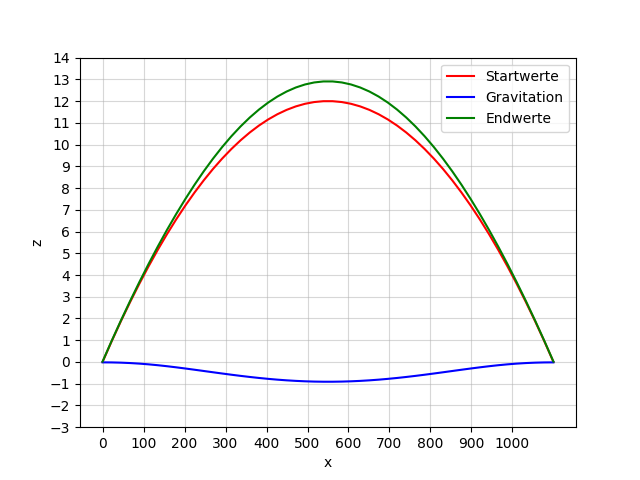

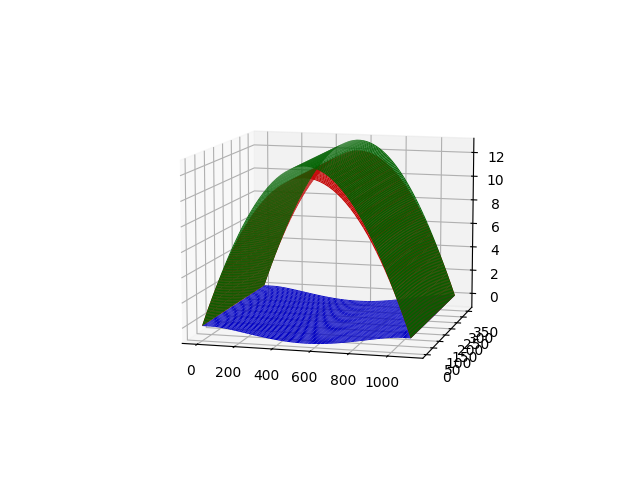

In [120]:
# Raster erzeugen
%matplotlib ipympl 
X = np.unique(x_SW)
Y = np.unique(y_SW)

X, Y = np.meshgrid(X, Y)
Z_SW=z_SW.reshape(len(Y), len(X))
Z_GRAV=z_GRAV.reshape(len(Y), len(X))
Z_EW=z_EW.reshape(len(Y), len(X))


fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot_surface(X, Y,Z_SW,color="red")          # startwerte
ax.plot_surface(X, Y,Z_GRAV,color="blue")       # gravitation
ax.plot_surface(X, Y,Z_EW,color="green")        # endwerte
ax.view_init(elev=10, azim=-75)

fig2, ax2 = plt.subplots()
y_mid = round(len(Y)/2)

ax2.plot(X[y_mid,:], Z_SW[y_mid,:],   'r', label='Startwerte')
ax2.plot(X[y_mid,:], Z_GRAV[y_mid,:], 'b', label='Gravitation')
ax2.plot(X[y_mid,:], Z_EW[y_mid,:],   'g', label='Endwerte')

ax2.set_xlabel("x")
ax2.set_ylabel("z")
ax2.legend()



minor_ticksX = np.arange(0,l,100)
minor_ticksY = np.arange(-c/4,5*c/4,1)

ax2.set_xticks(minor_ticksX)
ax2.set_yticks(minor_ticksY)
ax2.grid(True,alpha=0.5) #,which="major",alpha=0.2)


print(f"Länge={l}mm, Breite={b}mm, Dicke={t}mm \na={a}, c={c} -> f(x) =  {round(c,3)} - {round(a,3)}*(x-{l}/2)**2")
print('\nHöchster Wert:')

index_mitte = round(step/2)
print(' startwert:  ', z_SW[index_mitte])
print(' gravitation:', round(z_GRAV[index_mitte],4))
print(' endwert:    ', round(z_EW[index_mitte],4))
print("SOLLWERT 0.015\n")
print(' Endwert - Startwert:    ',z_EW[index_mitte] - z_SW[index_mitte])
print(' prozentuelle Änderung:    ', round(((100/z_SW[index_mitte]) * z_EW[index_mitte]),2),'%')


plt.show()

